In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
from pprint import pprint
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd
import json
import scipy
import pretty_midi

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
)
from scipy.stats import spearmanr

from src.utils import pickle_load

plt.rcParams["image.cmap"] = "Blues"

from src.evaluate_fun import (
    make_all_barcontrols,
    make_all_cosine_sim,
    make_all_pitchrange,
    make_all_repeatability,
    make_all_melodic_fidelity,
)
from src.evaluate_fun import make_all_avg_pitch
from src.evaluate_fun import (
    make_pitch_distribution_from_folder,
    make_pitch_distribution_from_midi,
)

from src.evaluate_accomontage import make_all_cosine_sim_accomontage

from pandarallel import pandarallel

pandarallel.initialize(progress_bar=False)

MNT_BASE_FOLDER = "/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations"

INFO: Pandarallel will run on 20 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
/!\ MELODY TOKENS WILL *NOT* INCLUDE CHORDS /!\
INFO: Pandarallel will run on 20 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


## Overall fidelity (chroma similarity)

In [3]:
# make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/musemorphose/')
make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/musemorphose/')

(0.9323402747280782, 0.09664493344819912)

In [4]:
# make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/meteor_nomel/')
make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_nomel/')

(0.918329156001292, 0.11053053984233865)

In [5]:
# make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/meteor_mel/')
make_all_cosine_sim('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_mel/')

(0.9272315572654578, 0.10185388165666434)

In [6]:
# FIGARO (in FIGARO folder)
# python src/evaluate.py --samples_dir=/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/figaro/max_iter\=16000\,max_bars\=8/

In [7]:
# With sheetsage transcription
# Make sure that you have analyzed the generated files ``python -m src.evaluate_accomontage''
print("Enforced instrumentation:", make_all_cosine_sim_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_sheetsage_gen_enforced/', skip_nomel=True))
print("Free instrumentation:", make_all_cosine_sim_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_sheetsage_gen_free/', skip_nomel=True))

W/o error: 327 / 332
Enforced instrumentation: (0.5898888742366222, 0.1322083970142019)
W/o error: 332 / 332
Free instrumentation: (0.598050763001092, 0.13135150150367578)


In [8]:
# With skyline approx
# Make sure that you have analyzed the generated files ``python -m src.evaluate_accomontage''
print("Enforced instrumentation:", make_all_cosine_sim_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_enforced/', skip_nomel=True))
print("Free instrumentation:", make_all_cosine_sim_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_free/', skip_nomel=True))

W/o error: 389 / 401
Enforced instrumentation: (0.7458143466043934, 0.10487757151843789)
W/o error: 395 / 401
Free instrumentation: (0.7556046095959743, 0.10475974461485538)


## Melodic fidelity (edit distance)

In [9]:
# make_all_melodic_fidelity('evaluations/symphony_n6h8_basiccls64_latent256_instrblocks_save')
make_all_melodic_fidelity('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/musemorphose/')

0 1 3 4 7 8 9 10 11 13 14 15 16 17 18 20 21 22 23 24 25 26 27 29 30 31 32 33 37 38 39 40 41 44 45 46 47 48 50 51 52 54 55 58 59 61 62 64 65 66 67 68 70 71 72 73 74 75 
Full sequence fidelity (↑): 0.512 +/- 0.13
Per beat fidelity (↑): 0.144
Per beat intersect (↑): 0.163


In [10]:
# make_all_melodic_fidelity('evaluations/symphony_n6h8_basiccls64_melodyfirst_nomel_con_save')
make_all_melodic_fidelity('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/meteor_nomel/')

0 1 2 3 4 8 9 10 11 13 14 15 16 17 19 21 22 23 24 25 27 28 29 30 31 32 33 35 36 37 39 41 42 43 44 47 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 67 68 69 70 71 72 74 75 76 
Full sequence fidelity (↑): 0.491 +/- 0.16
Per beat fidelity (↑): 0.157
Per beat intersect (↑): 0.182


In [11]:
# make_all_melodic_fidelity('evaluations/symphony_n6h8_basiccls64_melodyfirst_meltokens_trumpet_save')
# make_all_melodic_fidelity('evaluations/symphony_n6h8_basiccls64_melodyfirst_meltokens_cello')
# make_all_melodic_fidelity('evaluations/symphony_n6h8_basiccls64_melodyfirst_meltokens_flute_save')
make_all_melodic_fidelity('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/meteor_mel/')

1 2 3 4 5 6 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 27 28 29 30 32 34 35 36 39 40 41 42 43 44 45 47 48 49 50 53 54 55 56 58 59 60 62 63 65 67 69 71 74 75 76 77 
Full sequence fidelity (↑): 0.632 +/- 0.18
Per beat fidelity (↑): 0.421
Per beat intersect (↑): 0.463


In [12]:
from src.evaluate_figaro import melodic_similarity_figaro
melodic_similarity_figaro('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/mel_fidelity/figaro/')

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 
Full sequence fidelity (↑): 0.271 +/- 0.08
Per beat fidelity (↑): 0.000
Per beat intersect (↑): 0.000


In [14]:
from src.evaluate_accomontage import melodic_similarity_accomontage
melodic_similarity_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_free', skip_nomel=False)
melodic_similarity_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_free', skip_nomel=True)


Full sequence fidelity (↑): 0.670 +/- 0.17
Per beat fidelity (↑): 0.733
Per beat intersect (↑): 0.764

Full sequence fidelity (↑): 0.338 +/- 0.09
Per beat fidelity (↑): 0.015
Per beat intersect (↑): 0.022


In [15]:
melodic_similarity_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_enforced', skip_nomel=False)
melodic_similarity_accomontage('/mnt/nfs_share_magnet2/ldinhvie/accomontage3/leadsheet_skyline_gen_enforced', skip_nomel=True)


Full sequence fidelity (↑): 0.698 +/- 0.16
Per beat fidelity (↑): 0.764
Per beat intersect (↑): 0.769

Full sequence fidelity (↑): 0.344 +/- 0.10
Per beat fidelity (↑): 0.012
Per beat intersect (↑): 0.016


## Bar-Controllability

Entropy: 0.34101424369679795
Inference time: 94.75221720944016
Spearman: SignificanceResult(statistic=0.9405777115574103, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.92      0.45      0.60       908
         1.0       0.34      0.71      0.46       422
         2.0       0.49      0.38      0.43       406
         3.0       0.56      0.61      0.59       519
         4.0       0.54      0.66      0.60       395
         5.0       0.52      0.53      0.52       249
         6.0       0.62      0.58      0.60       302
         7.0       0.87      0.83      0.85       505

    accuracy                           0.58      3706
   macro avg       0.61      0.59      0.58      3706
weighted avg       0.66      0.58      0.59      3706



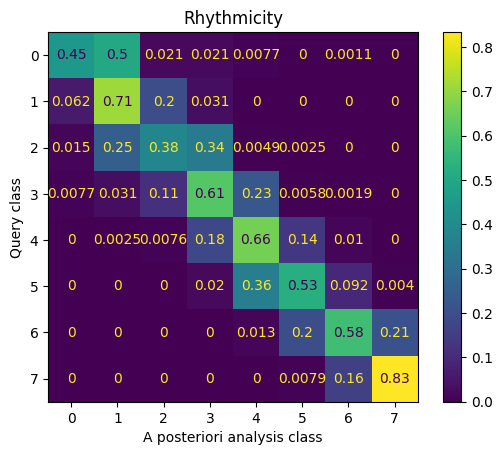

Spearman: SignificanceResult(statistic=0.9358233568055898, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.85      0.59      0.70       695
         1.0       0.38      0.62      0.47       343
         2.0       0.53      0.50      0.52       407
         3.0       0.48      0.42      0.45       432
         4.0       0.43      0.43      0.43       424
         5.0       0.48      0.45      0.46       470
         6.0       0.37      0.54      0.44       304
         7.0       0.86      0.80      0.83       631

    accuracy                           0.56      3706
   macro avg       0.55      0.54      0.54      3706
weighted avg       0.60      0.56      0.57      3706



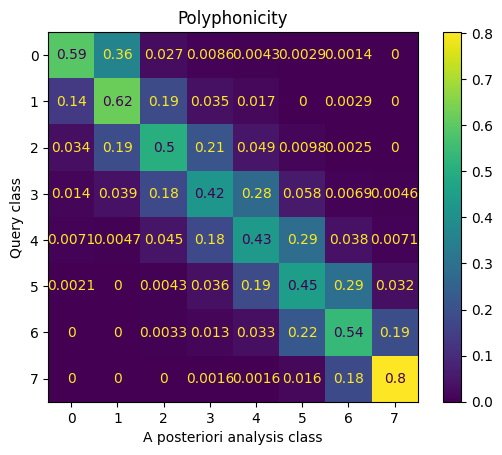

Spearman poly|rhythm SignificanceResult(statistic=0.1251729418836236, pvalue=2.046562137665798e-14)
Spearman rhythm|poly SignificanceResult(statistic=0.10091935844406194, pvalue=7.398976280016199e-10)


In [ ]:
make_all_barcontrols(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/musemorphose/').glob('**/*_cls.json')))

Entropy: 0.8124317731859673
Inference time: 133.4987777522705
Spearman: SignificanceResult(statistic=0.9717980804045135, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.97      0.52      0.68       637
         1.0       0.46      0.80      0.58       360
         2.0       0.72      0.56      0.63       383
         3.0       0.66      0.81      0.73       438
         4.0       0.76      0.72      0.74       429
         5.0       0.76      0.79      0.78       383
         6.0       0.70      0.82      0.76       316
         7.0       0.96      0.92      0.94       715

    accuracy                           0.74      3661
   macro avg       0.75      0.74      0.73      3661
weighted avg       0.79      0.74      0.75      3661



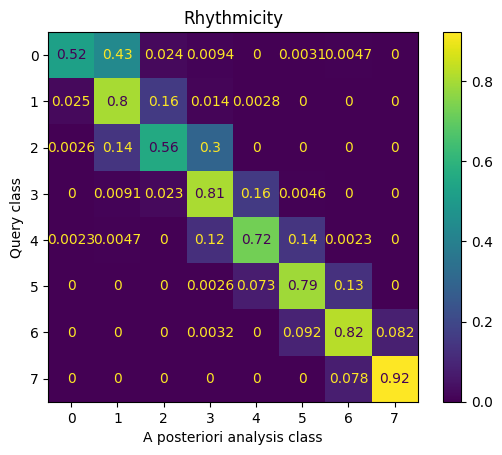

Spearman: SignificanceResult(statistic=0.951445282488333, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.91      0.67      0.77       765
         1.0       0.39      0.66      0.49       297
         2.0       0.50      0.55      0.52       331
         3.0       0.63      0.55      0.59       550
         4.0       0.55      0.53      0.54       440
         5.0       0.53      0.55      0.54       345
         6.0       0.54      0.65      0.59       354
         7.0       0.88      0.81      0.84       579

    accuracy                           0.63      3661
   macro avg       0.62      0.62      0.61      3661
weighted avg       0.67      0.63      0.64      3661



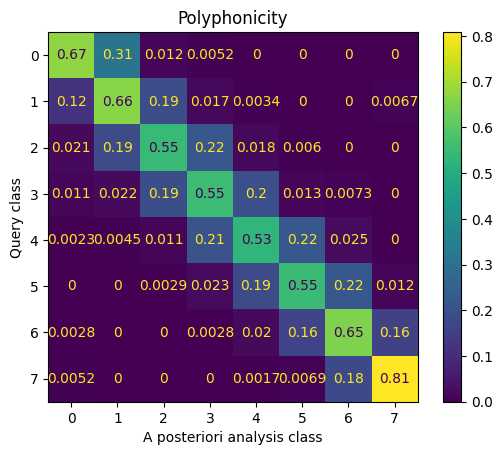

Spearman poly|rhythm SignificanceResult(statistic=0.12025217279348278, pvalue=2.877238465735311e-13)
Spearman rhythm|poly SignificanceResult(statistic=0.11038532330148988, pvalue=2.124652388154766e-11)


In [ ]:
make_all_barcontrols(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_nomel/').glob('**/*_cls.json')))

Entropy: 0.8942422777763767
Inference time: 96.63260542645173
Spearman: SignificanceResult(statistic=0.9501810030454102, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.97      0.49      0.65      1099
         1.0       0.36      0.85      0.50       447
         2.0       0.68      0.54      0.60       545
         3.0       0.60      0.80      0.69       600
         4.0       0.57      0.58      0.57       518
         5.0       0.55      0.50      0.53       424
         6.0       0.54      0.58      0.56       438
         7.0       0.92      0.67      0.78       581

    accuracy                           0.61      4652
   macro avg       0.65      0.63      0.61      4652
weighted avg       0.70      0.61      0.62      4652



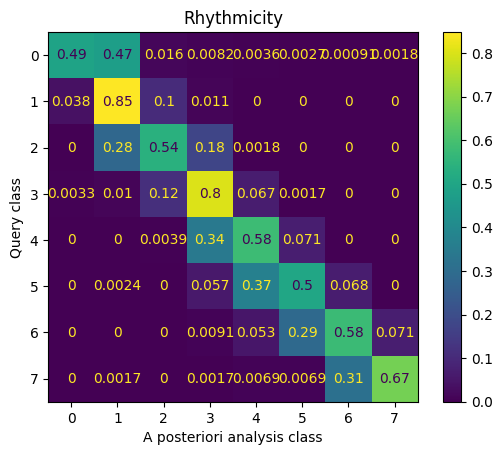

Spearman: SignificanceResult(statistic=0.9326315849257427, pvalue=0.0)
              precision    recall  f1-score   support

         0.0       0.88      0.51      0.65       919
         1.0       0.35      0.62      0.44       483
         2.0       0.51      0.49      0.50       549
         3.0       0.52      0.47      0.49       627
         4.0       0.43      0.42      0.43       567
         5.0       0.47      0.47      0.47       526
         6.0       0.45      0.59      0.51       362
         7.0       0.84      0.81      0.82       619

    accuracy                           0.54      4652
   macro avg       0.55      0.55      0.54      4652
weighted avg       0.59      0.54      0.55      4652



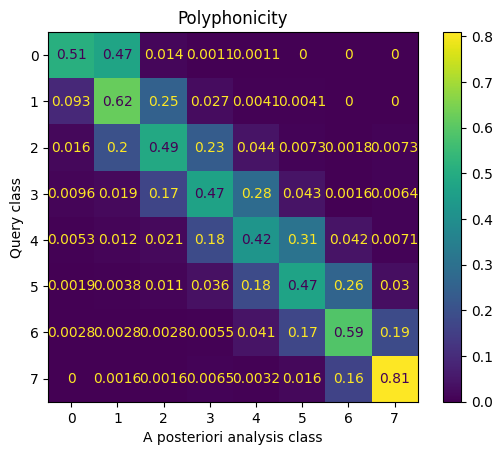

Spearman poly|rhythm SignificanceResult(statistic=0.09530868177633076, pvalue=7.333751570648367e-11)
Spearman rhythm|poly SignificanceResult(statistic=0.12430745478178237, pvalue=1.7513099019670002e-17)


In [ ]:
make_all_barcontrols(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_mel/').glob('**/*_cls.json')))

## Track-controllability

### Pitch range

Spearman: SignificanceResult(statistic=0.9259800293887632, pvalue=0.0)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
          10       0.00      0.00      0.00        26
          20       0.82      0.42      0.56       144
          30       0.70      0.63      0.67       241
          40       0.71      0.81      0.75       309
          50       0.77      0.74      0.76       381
          60       0.61      0.78      0.69       311
          70       0.67      0.76      0.71       373
          80       0.60      0.75      0.67       318
          90       0.47      0.59      0.52       262
         100       0.86      0.55      0.67       370
         110       0.81      0.53      0.64       111
         120       0.86      1.00      0.92         6
         130       0.00      0.00      0.00         7

    accuracy                           0.67      2877
   macro avg       0.56      0.54      0.54      2877
weighted 

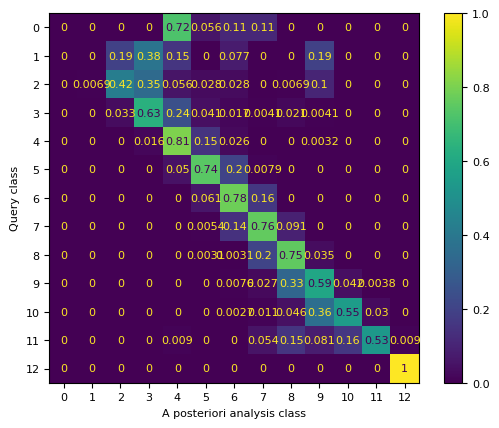

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/no_mel_pitchrange/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.8986418173247334, pvalue=0.0)
              precision    recall  f1-score   support

          10       0.00      0.00      0.00        20
          20       0.75      0.32      0.45        28
          30       0.94      0.58      0.72       186
          40       0.64      0.71      0.67       197
          50       0.84      0.80      0.82       264
          60       0.78      0.78      0.78       370
          70       0.60      0.77      0.68       336
          80       0.61      0.71      0.66       366
          90       0.72      0.70      0.71       339
         100       0.70      0.60      0.65       137
         110       0.06      0.03      0.04        34
         120       0.00      0.00      0.00        10
         130       0.00      0.00      0.00         1

    accuracy                           0.70      2288
   macro avg       0.51      0.46      0.47      2288
weighted avg       0.70      0.70      0.69      2288



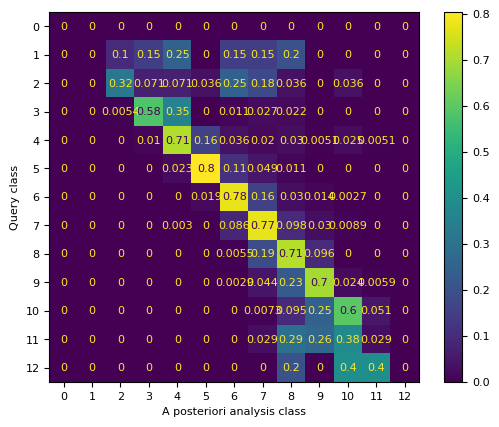

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/with_mel_pitchrange/').glob('**/*_cls.json')))

### Repeatability

Spearman: SignificanceResult(statistic=0.9292877289667767, pvalue=0.0)
              precision    recall  f1-score   support

           1       0.98      0.95      0.96      1358
           2       0.77      0.82      0.79       452
           3       0.66      0.63      0.64       419
           4       0.47      0.52      0.49       282
           5       0.37      0.37      0.37       203
           6       0.53      0.42      0.47       175
           7       0.30      0.25      0.27        69
           8       0.21      0.39      0.27        23
           9       0.14      0.50      0.22         6
          10       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.75      2987
   macro avg       0.40      0.44      0.41      2987
weighted avg       0.76      0.75      0.76      2987



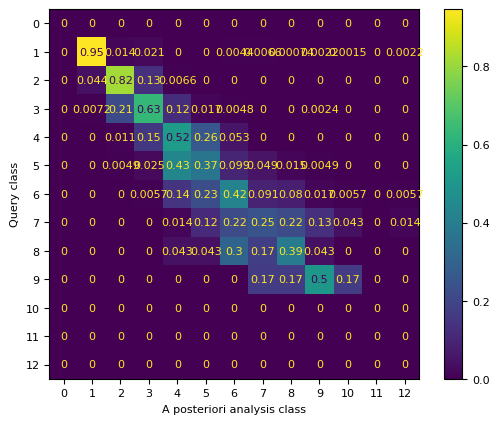

In [ ]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/no_mel_repeatability/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.8968117541384116, pvalue=0.0)
              precision    recall  f1-score   support

           1       0.99      0.90      0.94      1193
           2       0.83      0.79      0.81       469
           3       0.67      0.71      0.69       384
           4       0.48      0.44      0.46       403
           5       0.26      0.31      0.28       179
           6       0.29      0.31      0.30       148
           7       0.25      0.23      0.24        52
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.71      2832
   macro avg       0.31      0.31      0.31      2832
weighted avg       0.75      0.71      0.73      2832



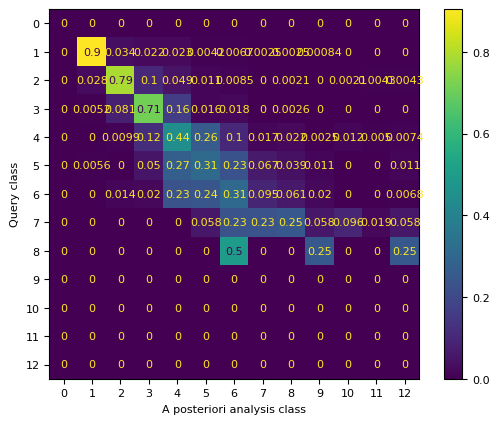

In [ ]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/with_mel_repeatability/').glob('**/*_cls.json')))

## Melodic pitch range per instrument

In [ ]:
token_files = list(Path(f"{MNT_BASE_FOLDER}/melody_instr/flute").glob('**/*.txt'))
mel_instrument = 'flute'
make_all_avg_pitch(token_files, mel_instrument)

0 1 2 3 5 7 8 9 10 11 12 13 14 15 16 18 19 21 22 23 24 25 27 28 29 ===================================
Avg note: (74) ({'name': 'Note_PitchClass', 'value': 'D'}, {'name': 'Note_Octave', 'value': 5})
Note - std: ({'name': 'Note_PitchClass', 'value': 'F#'}, {'name': 'Note_Octave', 'value': 4})
Note + std: ({'name': 'Note_PitchClass', 'value': 'A#'}, {'name': 'Note_Octave', 'value': 5})


In [ ]:
token_files = list(Path(f"{MNT_BASE_FOLDER}/melody_instr/bassoon").glob('**/*.txt'))
mel_instrument = 'bassoon'
make_all_avg_pitch(token_files, mel_instrument)

0 1 2 3 5 7 8 9 10 11 12 13 14 15 16 18 19 21 22 23 24 25 27 28 29 ===================================
Avg note: (46) ({'name': 'Note_PitchClass', 'value': 'A#'}, {'name': 'Note_Octave', 'value': 2})
Note - std: ({'name': 'Note_PitchClass', 'value': 'C#'}, {'name': 'Note_Octave', 'value': 2})
Note + std: ({'name': 'Note_PitchClass', 'value': 'G#'}, {'name': 'Note_Octave', 'value': 3})


In [ ]:
token_files = list(Path(f"{MNT_BASE_FOLDER}/melody_instr/trumpet").glob('**/*.txt'))
mel_instrument = 'trumpet'
make_all_avg_pitch(token_files, mel_instrument)

0 1 2 4 6 7 8 9 10 11 12 13 14 15 17 18 20 21 22 23 24 26 27 28 ===================================
Avg note: (67) ({'name': 'Note_PitchClass', 'value': 'G'}, {'name': 'Note_Octave', 'value': 4})
Note - std: ({'name': 'Note_PitchClass', 'value': 'B'}, {'name': 'Note_Octave', 'value': 3})
Note + std: ({'name': 'Note_PitchClass', 'value': 'D'}, {'name': 'Note_Octave', 'value': 5})


In [ ]:
token_files = list(Path(f"{MNT_BASE_FOLDER}/melody_instr/violin").glob('**/*.txt'))
mel_instrument = 'violin'
make_all_avg_pitch(token_files, mel_instrument)

0 1 2 3 5 7 8 9 10 11 12 13 14 15 16 18 19 21 22 23 24 25 27 28 29 ===================================
Avg note: (72) ({'name': 'Note_PitchClass', 'value': 'C'}, {'name': 'Note_Octave', 'value': 5})
Note - std: ({'name': 'Note_PitchClass', 'value': 'D#'}, {'name': 'Note_Octave', 'value': 4})
Note + std: ({'name': 'Note_PitchClass', 'value': 'A'}, {'name': 'Note_Octave', 'value': 5})


In [ ]:
token_files = list(Path(f"{MNT_BASE_FOLDER}/melody_instr/cello").glob('**/*.txt'))
mel_instrument = 'cello'
make_all_avg_pitch(token_files, mel_instrument)

0 1 2 3 5 7 8 9 10 11 12 13 14 15 16 18 19 21 22 23 24 25 27 28 29 ===================================
Avg note: (53) ({'name': 'Note_PitchClass', 'value': 'F'}, {'name': 'Note_Octave', 'value': 3})
Note - std: ({'name': 'Note_PitchClass', 'value': 'G#'}, {'name': 'Note_Octave', 'value': 2})
Note + std: ({'name': 'Note_PitchClass', 'value': 'D#'}, {'name': 'Note_Octave', 'value': 4})


## FIGARO controllability

In [7]:
sys.path.append('./figaro_eval')
from input_representation import InputRepresentation

In [8]:
midi_paths = list(Path('/home/ldinhvie/figaro/samples/controllability_save/figaro/max_iter=16000,max_bars=8/').glob('*.mid'))
analysis_files = list(Path('/home/ldinhvie/figaro/analysis_save').glob('*.json'))

def get_analysis_file(midi_file, analysis_files):
    for f in analysis_files:
        if midi_file.stem in f.stem and 'init' not in f.stem:
            return f
            
list_all_analysis = []
list_all_query = []

for file in tqdm(midi_paths):
    rep = InputRepresentation(str(file), strict=True)
    events = rep.get_remi_events()
    description = rep.get_description()

    analysis_file = get_analysis_file(file, analysis_files)
    query_full_piece = json.load(open(str(analysis_file), 'r'))

    analysis_cls = [x for x in description if x.startswith('Note Density')]
    query_cls = [x for x in query_full_piece if x.startswith('Note Density')][:len(analysis_cls)]
    
    list_all_analysis += [int(x.replace('Note Density_', '')) for x in analysis_cls]
    list_all_query += [int(x.replace('Note Density_', '')) for x in query_cls]

  0%|          | 0/90 [00:00<?, ?it/s]

Spearman: SignificanceResult(statistic=0.8667853394463215, pvalue=5.408386770457313e-224)
              precision    recall  f1-score   support

           0       0.95      0.61      0.75       335
           1       0.14      0.71      0.24        34
           2       0.32      0.50      0.39        36
           3       0.41      0.41      0.41        69
           4       0.27      0.29      0.28        38
           5       0.18      0.30      0.22        27
           6       0.14      0.17      0.15        30
           7       0.40      0.33      0.36        36
           8       0.27      0.15      0.19        27
           9       0.27      0.07      0.12        40
          10       0.15      0.09      0.11        22
          11       0.38      0.14      0.20        22
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.00         8
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00  

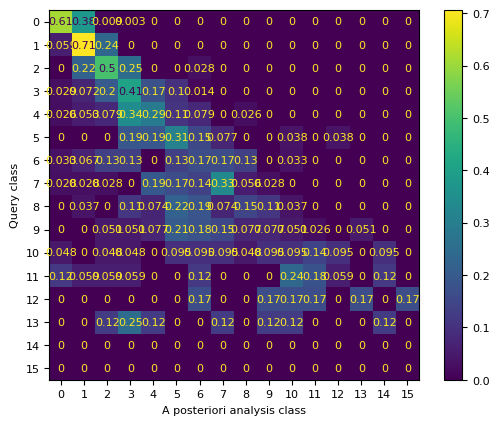

In [9]:
print("Spearman:", spearmanr(list_all_query, list_all_analysis))

print(classification_report(list_all_query, list_all_analysis, zero_division=0))
plt.rcParams.update({'font.size': 8})
disp = ConfusionMatrixDisplay(confusion_matrix(list_all_query, list_all_analysis, normalize='true', labels=np.arange(0, 16)))
disp.plot()
plt.ylabel('Query class')
plt.xlabel('A posteriori analysis class')
plt.show()

## Ensemble-wise evaluation

### METEOR with melody -- Orchestra

Entropy: 0.35776314949853244
Inference time: 126.15418829520543
Spearman: SignificanceResult(statistic=0.9527548797359374, pvalue=1.6559488916114488e-249)
              precision    recall  f1-score   support

           0       1.00      0.53      0.69        32
           1       0.46      0.78      0.58        23
           2       0.74      0.61      0.67        57
           3       0.58      0.63      0.61        57
           4       0.52      0.76      0.61        45
           5       0.70      0.66      0.68        65
           6       0.45      0.58      0.51        60
           7       0.91      0.72      0.80       141

    accuracy                           0.66       480
   macro avg       0.67      0.66      0.65       480
weighted avg       0.71      0.66      0.68       480



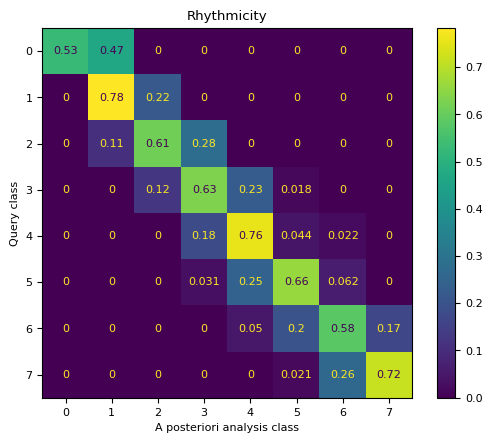

Spearman: SignificanceResult(statistic=0.8660103420419647, pvalue=5.529265289698506e-146)
              precision    recall  f1-score   support

           0       1.00      0.01      0.02        98
           1       0.15      0.11      0.13        55
           2       0.15      0.16      0.15        58
           3       0.19      0.30      0.23        63
           4       0.23      0.31      0.27        71
           5       0.32      0.66      0.43        44
           6       0.71      0.77      0.74        70
           7       0.71      0.57      0.63        21

    accuracy                           0.32       480
   macro avg       0.43      0.36      0.32       480
weighted avg       0.46      0.32      0.28       480



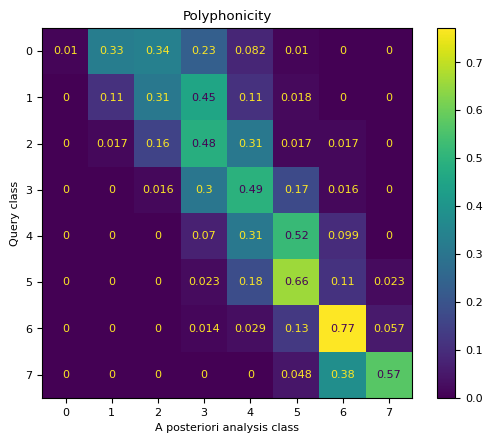

Spearman poly|rhythm SignificanceResult(statistic=-0.002768478429354006, pvalue=0.9517603659904754)
Spearman rhythm|poly SignificanceResult(statistic=0.024149100906497765, pvalue=0.5976535680141888)


In [ ]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/orchestra_with_mel/').glob('**/*_cls.json')))

In [ ]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_orchestra_raw')

0.9117731499713635

In [ ]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_orchestra_raw')

1 3 4 8 9 10 11 14 16 17 20 21 24 25 26 28 30 31 32 33 34 36 38 39 40 43 45 46 47 48 49 50 51 52 53 54 55 56 57 58 
Full sequence fidelity (↑): 0.720
Per beat fidelity (↑): 0.525
Per beat intersect (↑): 0.612


Spearman: SignificanceResult(statistic=0.9096657339144488, pvalue=0.0)
              precision    recall  f1-score   support

           1       1.00      0.90      0.95      2040
           2       0.81      0.81      0.81       719
           3       0.59      0.63      0.61       501
           4       0.43      0.48      0.45       374
           5       0.41      0.40      0.40       279
           6       0.29      0.32      0.31       161
           7       0.16      0.23      0.18        62
           8       0.07      0.14      0.09        21
           9       0.30      0.38      0.33        21
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.74      4178
   macro avg       0.34      0.36      0.35      4178
weighted avg       0.78      0.74      0.76      4178



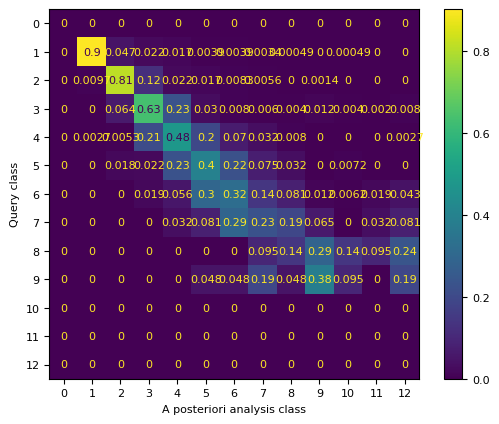

In [ ]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/orchestra_with_mel_repeatability/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.7800074479167474, pvalue=0.0)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        59
          10       1.00      0.01      0.03       140
          20       0.58      0.26      0.36       259
          30       0.77      0.44      0.56       503
          40       0.59      0.48      0.53       643
          50       0.51      0.62      0.56       553
          60       0.46      0.68      0.55       483
          70       0.47      0.81      0.59       460
          80       0.43      0.56      0.49       392
          90       0.60      0.55      0.58       350
         100       0.68      0.52      0.59       224
         110       0.46      0.11      0.17        56

    accuracy                           0.53      4122
   macro avg       0.55      0.42      0.42      4122
weighted avg       0.57      0.53      0.51      4122



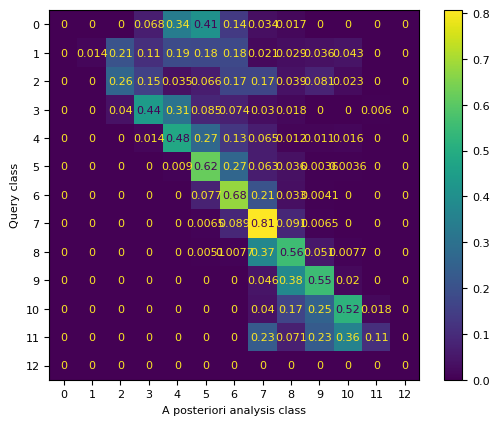

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/orchestra_with_mel_pitchrange/').glob('**/*_cls.json')))

### METEOR with melody -- Wind quintet

Entropy: 0.39694516785079187
Inference time: 13.725204074382782
Spearman: SignificanceResult(statistic=0.9396310538022281, pvalue=9.294854831723002e-225)
              precision    recall  f1-score   support

           0       0.96      0.50      0.65       137
           1       0.34      0.84      0.48        49
           2       0.49      0.55      0.52        51
           3       0.60      0.69      0.64        80
           4       0.56      0.64      0.60        66
           5       0.37      0.24      0.29        42
           6       0.39      0.23      0.29        31
           7       0.78      0.58      0.67        24

    accuracy                           0.55       480
   macro avg       0.56      0.53      0.52       480
weighted avg       0.63      0.55      0.56       480



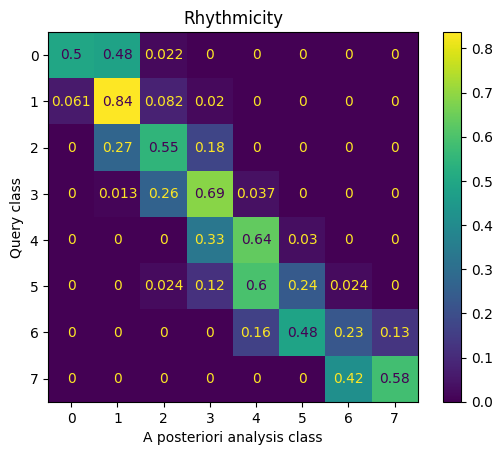

Spearman: SignificanceResult(statistic=0.8355348509128737, pvalue=2.0920487077307642e-126)
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        97
           1       0.23      0.42      0.29        43
           2       0.39      0.60      0.47        67
           3       0.38      0.58      0.46        77
           4       0.34      0.39      0.37        82
           5       0.34      0.23      0.27        53
           6       0.05      0.03      0.04        33
           7       0.00      0.00      0.00        28

    accuracy                           0.38       480
   macro avg       0.34      0.32      0.30       480
weighted avg       0.44      0.38      0.36       480



/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

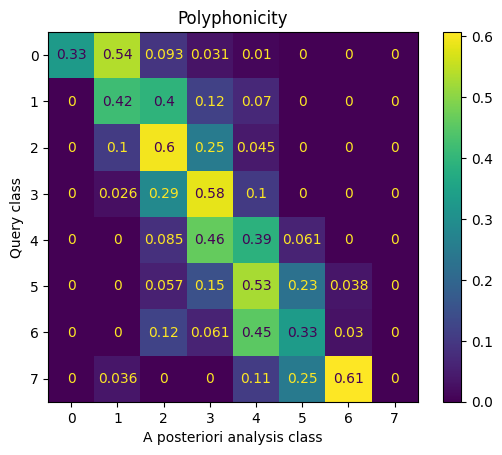

Spearman poly|rhythm SignificanceResult(statistic=0.056037886246464934, pvalue=0.22039040604692867)
Spearman rhythm|poly SignificanceResult(statistic=0.17783759544424732, pvalue=8.953268572508444e-05)


In [9]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/quintet_with_mel/').glob('**/*_cls.json')))

In [ ]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_windquintet_raw')

0.909394168913251

In [ ]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_windquintet_raw')

0 1 4 5 6 7 8 9 10 11 12 13 14 16 22 23 24 25 26 27 28 29 30 32 34 35 36 37 39 41 42 43 51 52 53 55 56 57 58 59 
Full sequence fidelity (↑): 0.651
Per beat fidelity (↑): 0.395
Per beat intersect (↑): 0.461


Spearman: SignificanceResult(statistic=0.8885512731740146, pvalue=0.0)
              precision    recall  f1-score   support

           1       0.99      0.78      0.88       719
           2       0.68      0.72      0.70       287
           3       0.61      0.67      0.64       322
           4       0.45      0.53      0.49       273
           5       0.45      0.38      0.41       287
           6       0.40      0.37      0.38       175
           7       0.11      0.20      0.14        35
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.62      2098
   macro avg       0.31      0.30      0.30      2098
weighted avg       0.68      0.62      0.65      2098



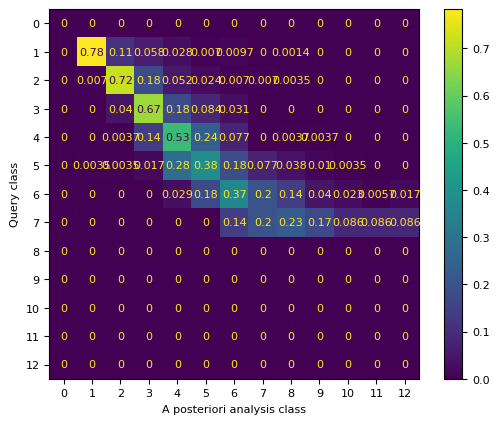

In [ ]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/quintet_with_mel_repeatability/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.8745344989321295, pvalue=0.0)
              precision    recall  f1-score   support

          10       0.00      0.00      0.00         0
          20       0.76      0.56      0.64        34
          30       0.94      0.40      0.56       126
          40       0.71      0.64      0.68       224
          50       0.67      0.54      0.60       252
          60       0.50      0.62      0.55       252
          70       0.50      0.67      0.57       287
          80       0.45      0.67      0.54       320
          90       0.59      0.59      0.59       322
         100       0.79      0.38      0.52       224
         110       0.50      0.05      0.10        56

    accuracy                           0.57      2097
   macro avg       0.58      0.47      0.49      2097
weighted avg       0.61      0.57      0.56      2097



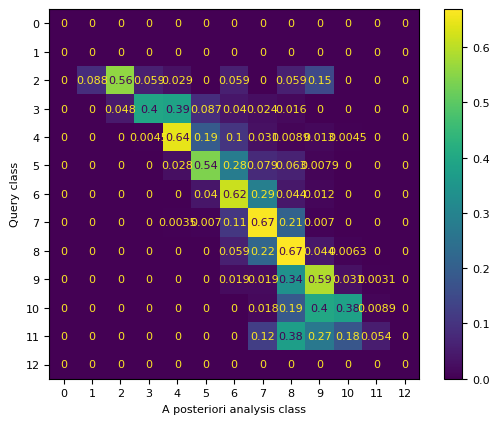

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/quintet_with_mel_pitchrange/').glob('**/*_cls.json')))

### METEOR with melody -- Duet

Entropy: 0.36643232777171625
Inference time: 8.889790042241414
Spearman: SignificanceResult(statistic=0.9359026140185188, pvalue=9.786656429431268e-219)
              precision    recall  f1-score   support

           0       0.91      0.53      0.67       120
           1       0.28      0.77      0.41        43
           2       0.42      0.46      0.44        48
           3       0.28      0.48      0.35        48
           4       0.45      0.27      0.34        71
           5       0.35      0.39      0.37        46
           6       0.52      0.24      0.33        55
           7       0.90      0.71      0.80        49

    accuracy                           0.47       480
   macro avg       0.51      0.48      0.46       480
weighted avg       0.58      0.47      0.49       480



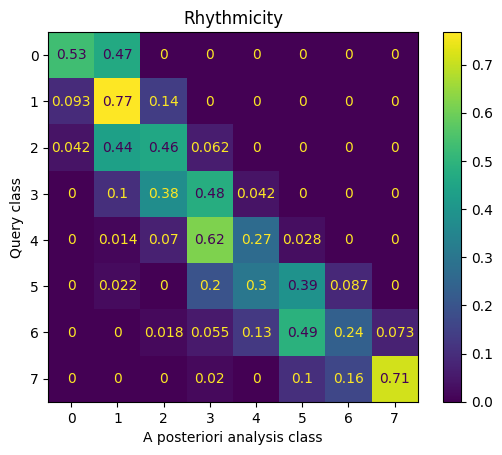

Spearman: SignificanceResult(statistic=0.7151919673542512, pvalue=2.2153575376944015e-76)
              precision    recall  f1-score   support

           0       0.51      0.79      0.62       108
           1       0.17      0.37      0.23        70
           2       0.08      0.12      0.09        41
           3       0.07      0.06      0.07        49
           4       0.00      0.00      0.00        40
           5       0.18      0.03      0.05        67
           6       0.17      0.03      0.05        34
           7       1.00      0.04      0.08        71

    accuracy                           0.26       480
   macro avg       0.27      0.18      0.15       480
weighted avg       0.34      0.26      0.21       480



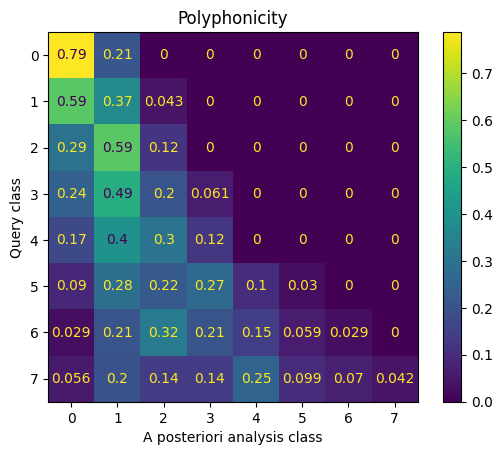

Spearman poly|rhythm SignificanceResult(statistic=0.2257328388108862, pvalue=5.813613486064832e-07)
Spearman rhythm|poly SignificanceResult(statistic=0.25717498373385106, pvalue=1.0896218550714863e-08)


In [ ]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/duet_with_mel/').glob('**/*_cls.json')))

In [ ]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_windduet_raw')

0.8373178866549906

In [ ]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melfull_windduet_raw')

0 2 3 6 7 8 9 10 11 14 16 18 19 22 23 25 27 28 29 30 31 32 33 34 35 36 37 38 40 41 43 44 46 47 50 51 52 56 57 59 
Full sequence fidelity (↑): 0.650
Per beat fidelity (↑): 0.462
Per beat intersect (↑): 0.529


Spearman: SignificanceResult(statistic=0.7112533287285946, pvalue=5.882474599184407e-132)
              precision    recall  f1-score   support

          20       1.00      1.00      1.00         1
          30       0.43      1.00      0.60         3
          40       1.00      0.47      0.64        88
          50       0.86      0.49      0.62       103
          60       0.42      0.42      0.42        85
          70       0.46      0.65      0.54        99
          80       0.30      0.65      0.41       112
          90       0.45      0.51      0.48       179
         100       0.77      0.48      0.59       110
         110       0.50      0.01      0.03        70

    accuracy                           0.49       850
   macro avg       0.62      0.57      0.53       850
weighted avg       0.58      0.49      0.48       850



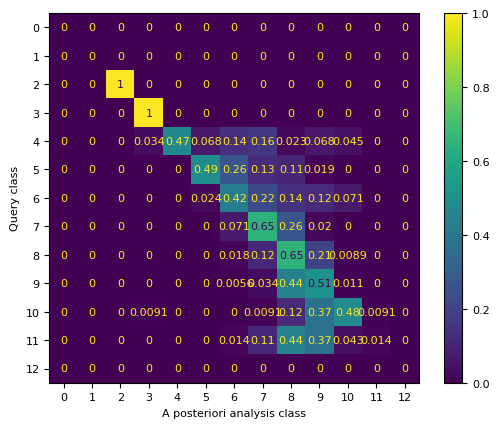

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/duet_with_mel_pitchrange/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.7862275998237723, pvalue=1.0717613526825796e-175)
              precision    recall  f1-score   support

           1       0.99      0.56      0.72       262
           2       0.24      0.52      0.33        42
           3       0.55      0.67      0.61       138
           4       0.60      0.60      0.60       166
           5       0.31      0.40      0.35        98
           6       0.59      0.37      0.46       126
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0

    accuracy                           0.54       832
   macro avg       0.33      0.31      0.31       832
weighted avg       0.66      0.54      0.57       832



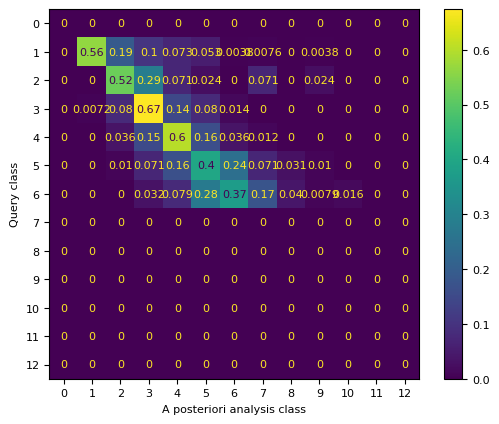

In [ ]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/duet_with_mel_repeatability/').glob('**/*_cls.json')))

### Multi-track MuseMorphose -- Orchestra (DOUBT)

Entropy: 0.7277546787807031
Inference time: 96.02107029446101
Spearman: SignificanceResult(statistic=0.921188688828666, pvalue=8.677854631986125e-195)
              precision    recall  f1-score   support

           0       0.86      0.30      0.45        79
           1       0.43      0.63      0.51        57
           2       0.31      0.23      0.27        48
           3       0.32      0.47      0.38        34
           4       0.48      0.64      0.55        50
           5       0.50      0.39      0.44        54
           6       0.61      0.62      0.61        60
           7       0.81      0.96      0.88        90

    accuracy                           0.56       472
   macro avg       0.54      0.53      0.51       472
weighted avg       0.59      0.56      0.54       472



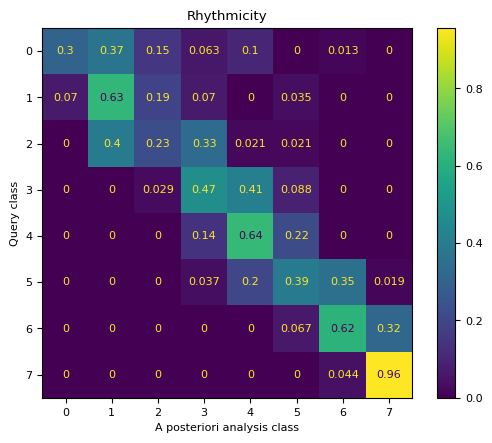

Spearman: SignificanceResult(statistic=0.675543608211017, pvalue=3.4139235422675864e-64)
              precision    recall  f1-score   support

           0       0.40      0.01      0.02       177
           1       0.04      0.02      0.03        48
           2       0.09      0.08      0.08        51
           3       0.04      0.06      0.05        49
           4       0.07      0.15      0.09        48
           5       0.11      0.32      0.16        28
           6       0.19      0.59      0.28        29
           7       0.74      0.88      0.80        42

    accuracy                           0.17       472
   macro avg       0.21      0.26      0.19       472
weighted avg       0.26      0.17      0.13       472



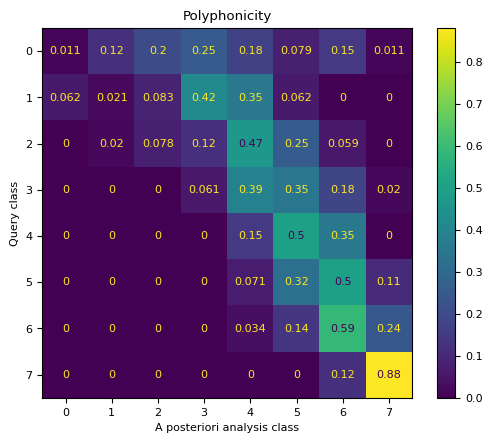

Spearman poly|rhythm SignificanceResult(statistic=-0.07394086790376865, pvalue=0.10863822089229412)
Spearman rhythm|poly SignificanceResult(statistic=0.17772128476130045, pvalue=0.00010368569710651183)


In [ ]:
make_all_barcontrols(list(Path('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_orchestra_raw').glob('**/*_cls.json')))

In [ ]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_orchestra_raw')

0.9472486893837807

In [10]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_orchestra_raw')

2 3 4 5 6 7 8 9 10 11 13 14 16 17 18 19 20 21 23 24 25 27 28 29 30 31 34 35 36 37 39 40 41 43 44 45 47 50 51 52 53 54 55 56 58 59 60 61 63 65 66 67 68 69 70 71 74 75 77 79 
Full sequence fidelity (↑): 0.511
Per beat fidelity (↑): 0.165
Per beat intersect (↑): 0.194


### Multi-track MuseMorphose -- quintet

In [ ]:
make_all_barcontrols(list(Path('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windquintet_raw').glob('**/*_cls.json')))

In [ ]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windquintet_raw')

In [ ]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windquintet_raw')

### Multi-track MuseMorphose -- Duet

Entropy: 0.707799775863431
Inference time: 39.33348491362163
Spearman: SignificanceResult(statistic=0.918830380757096, pvalue=5.474492859926681e-181)
              precision    recall  f1-score   support

           0       0.84      0.52      0.64       143
           1       0.26      0.61      0.36        54
           2       0.50      0.35      0.41        48
           3       0.50      0.56      0.53        32
           4       0.39      0.38      0.39        29
           5       0.44      0.51      0.47        35
           6       0.57      0.57      0.57        35
           7       1.00      0.80      0.89        69

    accuracy                           0.55       445
   macro avg       0.56      0.54      0.53       445
weighted avg       0.65      0.55      0.58       445



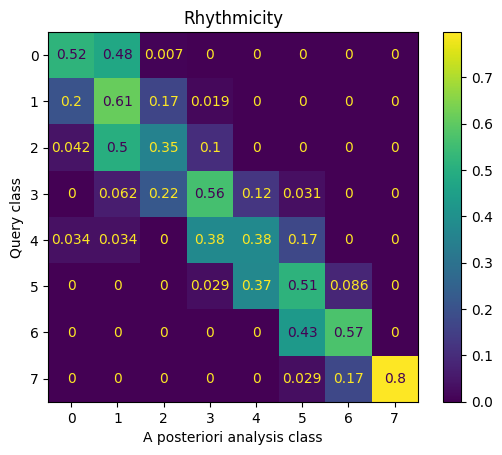

Spearman: SignificanceResult(statistic=0.710466587029187, pvalue=1.3401076221507024e-69)
              precision    recall  f1-score   support

           0       0.49      0.86      0.62       105
           1       0.21      0.41      0.28        46
           2       0.19      0.14      0.16        69
           3       0.08      0.09      0.09        56
           4       0.12      0.05      0.07        55
           5       0.08      0.03      0.04        39
           6       0.20      0.05      0.08        39
           7       1.00      0.14      0.24        36

    accuracy                           0.30       445
   macro avg       0.29      0.22      0.20       445
weighted avg       0.30      0.30      0.25       445



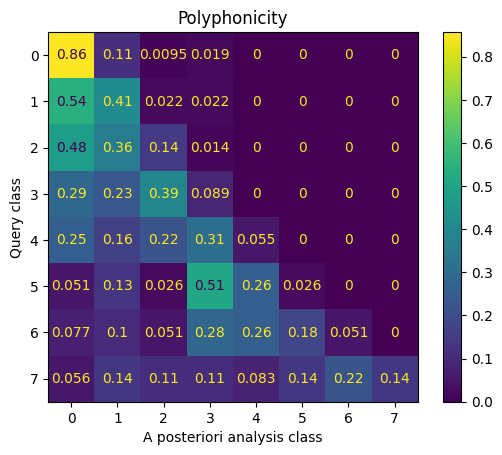

Spearman poly|rhythm SignificanceResult(statistic=0.40129493487108026, pvalue=1.1996251087110296e-18)
Spearman rhythm|poly SignificanceResult(statistic=0.2036942117739577, pvalue=1.488855233700046e-05)


In [110]:
make_all_barcontrols(list(Path('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windduet_raw').glob('**/*_cls.json')))

In [111]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windduet_raw')

0.8878892318688465

In [112]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_latent256_instrblocks_windduet_raw')

0 3 4 5 8 9 10 11 12 13 14 15 17 18 19 21 22 23 25 26 27 30 31 33 34 35 37 38 40 41 43 44 45 46 47 50 51 52 53 54 55 56 57 60 62 64 65 66 67 68 69 70 71 72 73 74 76 77 78 
Full sequence fidelity (↑): 0.479
Per beat fidelity (↑): 0.145
Per beat intersect (↑): 0.165


### METEOR no melody -- Orchestra

Entropy: 0.2799529662404493
Inference time: 106.3953951438268
Spearman: SignificanceResult(statistic=0.9353873753895952, pvalue=6.22675437883986e-218)
              precision    recall  f1-score   support

           0       1.00      0.34      0.51       145
           1       0.30      0.76      0.43        49
           2       0.59      0.50      0.54        68
           3       0.61      0.69      0.65        74
           4       0.36      0.60      0.45        25
           5       0.75      0.80      0.77        30
           6       0.84      0.88      0.86        42
           7       0.92      0.96      0.94        47

    accuracy                           0.61       480
   macro avg       0.67      0.69      0.64       480
weighted avg       0.74      0.61      0.61       480



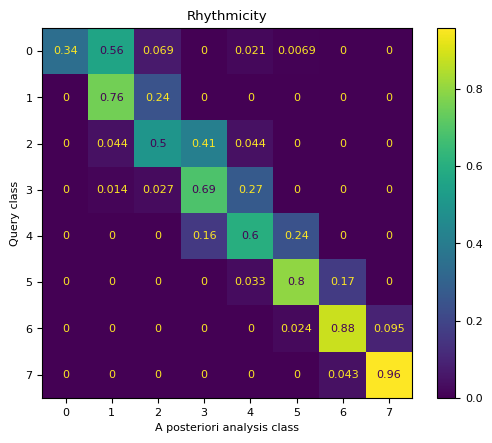

Spearman: SignificanceResult(statistic=0.7824518000849433, pvalue=2.1726322794632858e-100)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       122
           1       0.29      0.21      0.24        53
           2       0.22      0.18      0.20        76
           3       0.13      0.25      0.17        52
           4       0.24      0.37      0.29        60
           5       0.17      0.35      0.23        31
           6       0.16      0.50      0.25        22
           7       0.82      0.72      0.77        64

    accuracy                           0.27       480
   macro avg       0.25      0.32      0.27       480
weighted avg       0.24      0.27      0.24       480



/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

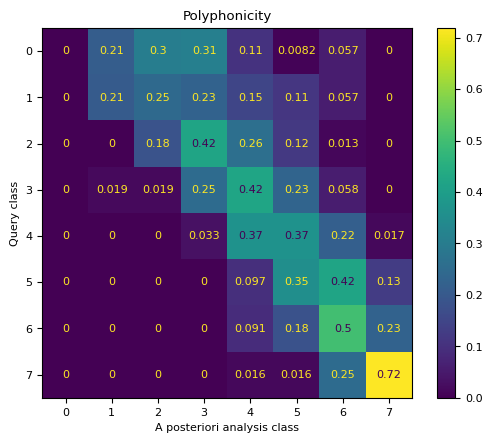

Spearman poly|rhythm SignificanceResult(statistic=-0.026406069102914136, pvalue=0.5638582339132854)
Spearman rhythm|poly SignificanceResult(statistic=0.03736907001513368, pvalue=0.41400500007952945)


In [27]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/orchestra_no_mel_save/').glob('**/*_cls.json')))

In [11]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_orchestra')

0.9171690663290993

In [10]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_orchestra')

0 1 2 3 4 5 7 8 9 10 11 12 13 14 16 18 19 21 23 24 30 31 32 33 34 35 37 38 39 40 42 43 44 45 46 47 48 49 50 51 52 55 57 59 60 61 62 63 64 66 67 69 70 71 72 74 75 77 78 79 
Full sequence fidelity (↑): 0.493
Per beat fidelity (↑): 0.093
Per beat intersect (↑): 0.106


Spearman: SignificanceResult(statistic=0.957729335245098, pvalue=0.0)
              precision    recall  f1-score   support

           1       0.98      0.99      0.98      1510
           2       0.87      0.92      0.89       504
           3       0.76      0.75      0.75       552
           4       0.64      0.59      0.61       647
           5       0.46      0.42      0.44       466
           6       0.36      0.34      0.35       262
           7       0.35      0.32      0.33       146
           8       0.07      0.12      0.09        42
           9       0.27      0.25      0.26        48
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.74      4177
   macro avg       0.39      0.39      0.39      4177
weighted avg       0.75      0.74      0.74      4177



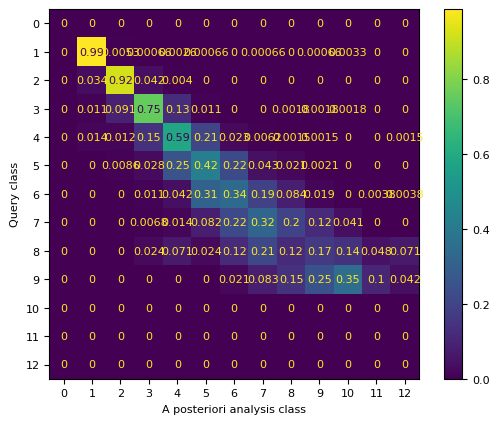

In [71]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/orchestra_no_mel_repeatability/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.7985481691427858, pvalue=0.0)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
          10       0.50      0.01      0.03       140
          20       0.59      0.24      0.35       266
          30       0.78      0.39      0.52       539
          40       0.60      0.66      0.63       574
          50       0.56      0.73      0.63       455
          60       0.53      0.76      0.62       476
          70       0.59      0.81      0.68       462
          80       0.62      0.81      0.70       391
          90       0.65      0.67      0.66       419
         100       0.74      0.68      0.70       305
         110       0.66      0.42      0.51        83

    accuracy                           0.61      4194
   macro avg       0.57      0.51      0.50      4194
weighted avg       0.61      0.61      0.58      4194



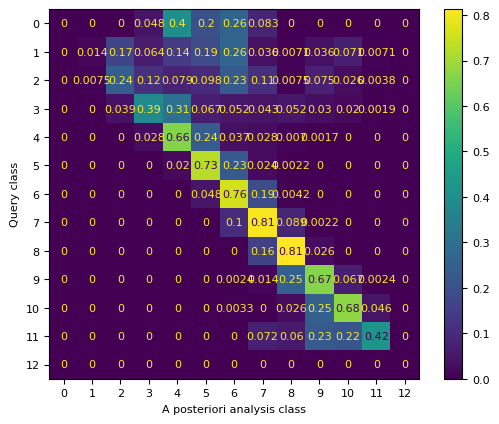

In [ ]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/orchestra_no_mel_pitchrange/').glob('**/*_cls.json')))

### METEOR no melody -- Quintet

Entropy: 0.33607715810476174
Inference time: 33.41467923323314
Spearman: SignificanceResult(statistic=0.9714491521869908, pvalue=8.341070377905239e-301)
              precision    recall  f1-score   support

           0       0.97      0.62      0.76       115
           1       0.40      0.92      0.55        39
           2       0.76      0.58      0.66        55
           3       0.81      0.87      0.84        70
           4       0.78      0.80      0.79        54
           5       0.73      0.75      0.74        51
           6       0.80      0.75      0.78        44
           7       0.94      0.92      0.93        52

    accuracy                           0.75       480
   macro avg       0.78      0.78      0.76       480
weighted avg       0.81      0.75      0.76       480



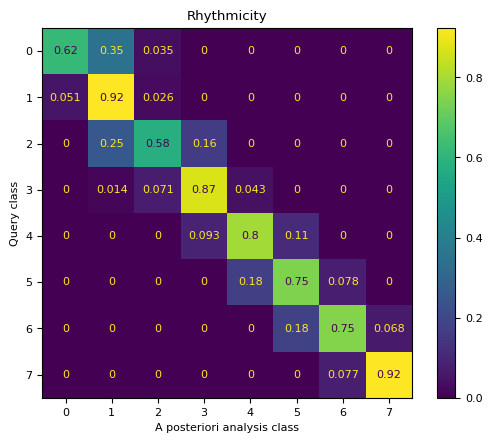

Spearman: SignificanceResult(statistic=0.8596736174050867, pvalue=1.5453425526931984e-141)
              precision    recall  f1-score   support

           0       0.86      0.31      0.46       116
           1       0.28      0.59      0.38        51
           2       0.41      0.62      0.49        56
           3       0.62      0.56      0.59        78
           4       0.29      0.45      0.35        38
           5       0.12      0.24      0.16        29
           6       0.17      0.24      0.20        37
           7       1.00      0.09      0.17        75

    accuracy                           0.39       480
   macro avg       0.47      0.39      0.35       480
weighted avg       0.59      0.39      0.38       480



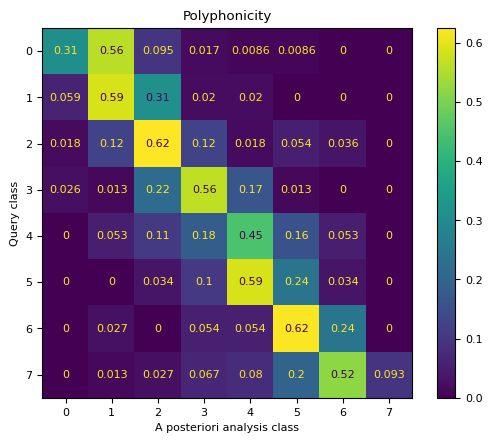

Spearman poly|rhythm SignificanceResult(statistic=0.0673752393649427, pvalue=0.14049664478946502)
Spearman rhythm|poly SignificanceResult(statistic=0.08538303852543563, pvalue=0.06159695494772916)


In [ ]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/quintet_no_mel/').glob('**/*_cls.json')))

In [86]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_windquintet')

0.9034454638245869

In [87]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_windquintet')

0 1 2 3 4 5 6 7 9 11 12 13 14 16 17 19 20 21 22 24 25 26 27 29 30 31 33 35 36 37 

39 40 41 42 43 44 47 48 49 50 52 53 55 56 57 58 59 62 64 65 68 69 70 71 73 75 76 77 78 79 
Full sequence fidelity (↑): 0.519
Per beat fidelity (↑): 0.123
Per beat intersect (↑): 0.145


Spearman: SignificanceResult(statistic=0.9605200900019287, pvalue=0.0)
              precision    recall  f1-score   support

           1       0.99      0.98      0.98       797
           2       0.84      0.85      0.85       279
           3       0.67      0.72      0.69       279
           4       0.50      0.53      0.51       273
           5       0.45      0.36      0.40       245
           6       0.54      0.45      0.49       175
           7       0.27      0.33      0.30        42
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0

    accuracy                           0.74      2090
   macro avg       0.39      0.38      0.38      2090
weighted avg       0.75      0.74      0.74      2090



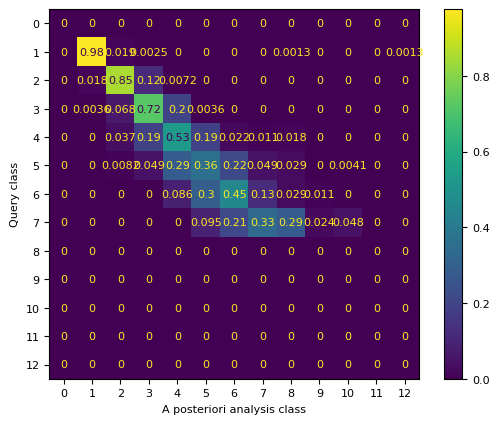

In [70]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/quintet_no_mel_repeatability/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.85304724209374, pvalue=0.0)
              precision    recall  f1-score   support

          10       0.00      0.00      0.00         0
          20       0.73      0.32      0.45        74
          30       0.95      0.56      0.70       201
          40       0.82      0.84      0.83       327
          50       0.85      0.85      0.85       318
          60       0.80      0.76      0.78       321
          70       0.57      0.76      0.65       238
          80       0.46      0.76      0.57       174
          90       0.58      0.67      0.63       196
         100       0.83      0.53      0.64       154
         110       0.76      0.42      0.54        84
         120       0.00      0.00      0.00         0

    accuracy                           0.71      2087
   macro avg       0.61      0.54      0.55      2087
weighted avg       0.75      0.71      0.71      2087



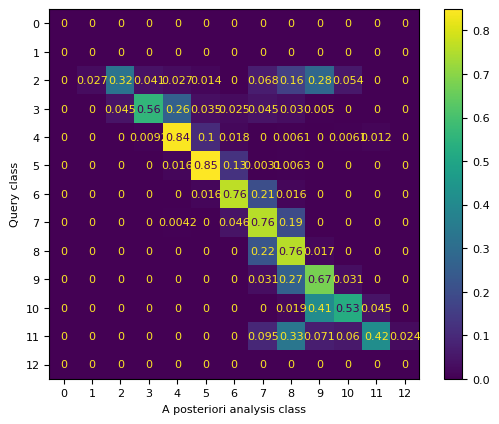

In [69]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/quintet_no_mel_pitchrange/').glob('**/*_cls.json')))

### METEOR no melody -- Duet

Entropy: 0.3973282641054489
Inference time: 4.4332166809146685
Spearman: SignificanceResult(statistic=0.9667068935776395, pvalue=2.5130583566868146e-139)
              precision    recall  f1-score   support

           0       0.98      0.84      0.91        57
           1       0.38      0.64      0.47        14
           2       0.31      0.36      0.33        14
           3       0.61      0.61      0.61        31
           4       0.14      0.36      0.20        11
           5       0.47      0.20      0.28        35
           6       0.65      0.80      0.72        30
           7       0.97      0.76      0.85        42

    accuracy                           0.63       234
   macro avg       0.56      0.57      0.55       234
weighted avg       0.69      0.63      0.65       234



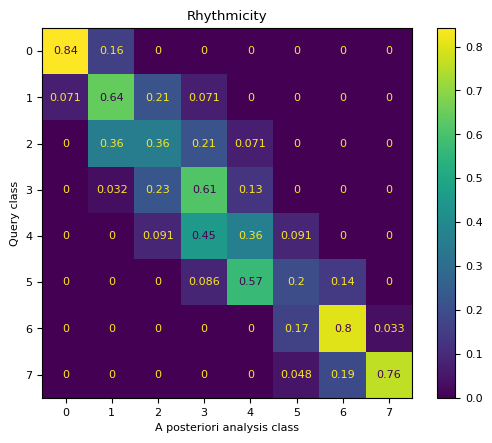

Spearman: SignificanceResult(statistic=0.7821813671551526, pvalue=1.4246044398998138e-49)
              precision    recall  f1-score   support

           0       0.73      0.74      0.74        62
           1       0.10      0.60      0.16        10
           2       0.06      0.14      0.09        21
           3       0.03      0.04      0.03        24
           4       0.06      0.04      0.05        25
           5       0.00      0.00      0.00        28
           6       0.00      0.00      0.00        30
           7       0.00      0.00      0.00        34

    accuracy                           0.24       234
   macro avg       0.12      0.20      0.13       234
weighted avg       0.21      0.24      0.22       234



/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/nfs_share_magnet2/ldinhvie/envs/envmusemorphose_share/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

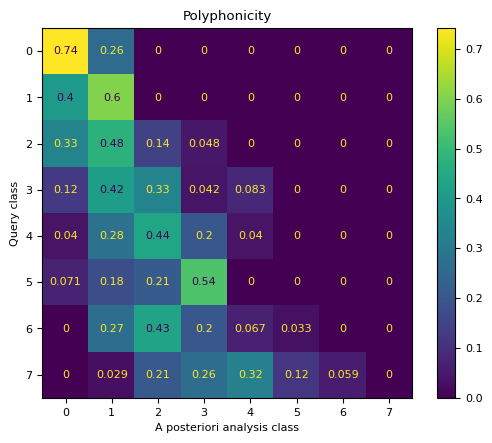

Spearman poly|rhythm SignificanceResult(statistic=0.1424794186415938, pvalue=0.02933365498917995)
Spearman rhythm|poly SignificanceResult(statistic=0.10361578342847266, pvalue=0.11392682694426418)


In [33]:
make_all_barcontrols(list(Path(f'{MNT_BASE_FOLDER}/bar_controllability/duet_no_mel/').glob('**/*_cls.json')))

In [89]:
make_all_cosine_sim('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_windduet')

0.8368420365993339

In [90]:
make_all_melodic_fidelity('evaluations/ensembles/symphony_n6h8_basiccls64_melodyfirst_nomel_con_windduet')

1 5 7 8 9 10 12 13 14 15 16 17 18 21 23 24 25 27 28 29 30 31 32 33 34 36 37 38 40 41 42 43 44 45 47 48 49 50 52 53 54 55 56 57 58 59 60 61 62 63 65 66 68 70 71 74 75 76 78 
Full sequence fidelity (↑): 0.457
Per beat fidelity (↑): 0.093
Per beat intersect (↑): 0.113


Spearman: SignificanceResult(statistic=0.872822909161093, pvalue=8.260471225544649e-261)
              precision    recall  f1-score   support

          30       0.00      0.00      0.00         0
          40       0.93      0.83      0.88        96
          50       0.77      0.82      0.80        96
          60       0.85      0.80      0.83       110
          70       0.61      0.73      0.66       110
          80       0.57      0.84      0.67        98
          90       0.66      0.77      0.71       112
         100       0.94      0.69      0.79       154
         110       0.89      0.30      0.45        56
         120       0.00      0.00      0.00         0

    accuracy                           0.74       832
   macro avg       0.62      0.58      0.58       832
weighted avg       0.78      0.74      0.74       832



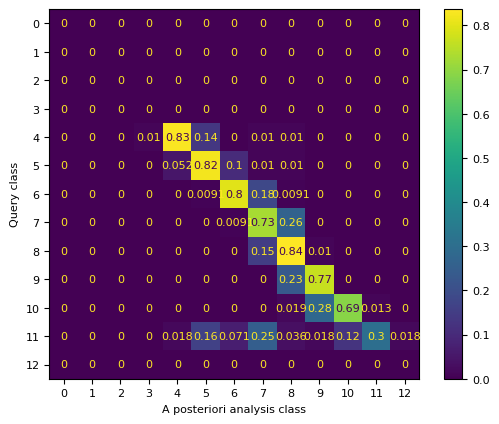

In [61]:
make_all_pitchrange(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/duet_no_mel_pitchrange/').glob('**/*_cls.json')))

Spearman: SignificanceResult(statistic=0.9498864024547359, pvalue=0.0)
              precision    recall  f1-score   support

           1       1.00      0.90      0.95       308
           2       0.72      0.80      0.76       112
           3       0.66      0.53      0.58       112
           4       0.34      0.51      0.41        84
           5       0.45      0.50      0.48        98
           6       0.84      0.42      0.56       140
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0

    accuracy                           0.68       854
   macro avg       0.40      0.37      0.37       854
weighted avg       0.76      0.68      0.70       854



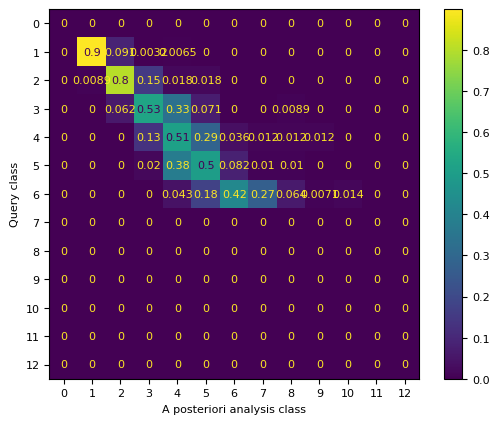

In [63]:
make_all_repeatability(list(Path(f'{MNT_BASE_FOLDER}/track_controllability/duet_no_mel_repeatability/').glob('**/*_cls.json')))

## Orchestration realisticness

In [ ]:
symphonynet_distrib = pickle_load('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/symphonynet_distrib.pickle')
lmd_distrib = pickle_load('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/lmd_distrib.pickle')

ref_distrib = dict(
    [(track, dict(
        [(pitch, 0) for pitch in range(128)
    ])) for track in range(128)]
)

for pitch_distrib in [symphonynet_distrib, lmd_distrib]:
    for track in range(128):
        for pitch in range(128):
            ref_distrib[track][pitch] += pitch_distrib[track][pitch]

In [ ]:
max_files = 300

accomontage_count = make_pitch_distribution_from_folder(list(Path('/home/ldinhvie/Structured-Arrangement-Code/test').glob('**/Ours.mid'))[:max_files])

musemorphose_count = make_pitch_distribution_from_folder(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/musemorphose/').glob('**/*melody.mid'))[:max_files])
meteor_count = make_pitch_distribution_from_folder(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_nomel/').glob('**/*melody.mid'))[:max_files])
meteor_mel_count = make_pitch_distribution_from_folder(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/meteor_mel/').glob('**/*melody.mid'))[:max_files])
figaro_count = make_pitch_distribution_from_folder(list(Path('/mnt/nfs_share_magnet2/ldinhvie/multitrack_generations/instru/figaro/').glob('**/*_melody.mid'))[:max_files])

def make_dict_count_models(program):
    return {
        'ref_lmd': np.array(list(lmd_distrib[program].values())),
        'ref_symphonynet': np.array(list(symphonynet_distrib[program].values())),
        'ref': np.array(list(ref_distrib[program].values())),
        'accomontage': np.array(list(accomontage_count[program].values())),
        'figaro': np.array(list(figaro_count[program].values())),
        'musemorphose': np.array(list(musemorphose_count[program].values())),
        'meteor_nomel': np.array(list(meteor_count[program].values())),
        'meteor_mel': np.array(list(meteor_mel_count[program].values())),
    }

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

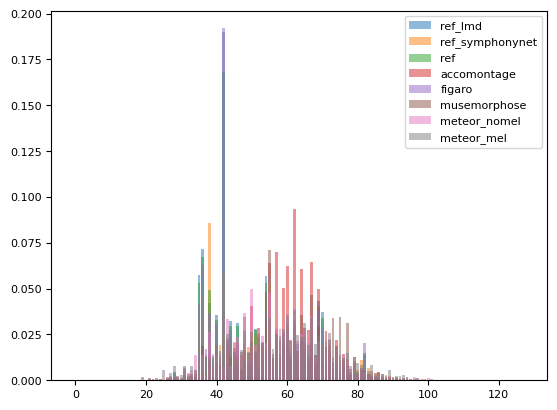

In [ ]:
## Single file
program = 0

midi_file = '/mnt/nfs_share_magnet2/ldinhvie/meteor_userstudy/066/accomontage_arrangement_band-03_nomel.mid'
# midi_file = '/mnt/nfs_share_magnet2/ldinhvie/meteor_userstudy/meteor/id0_bar0_sample01_poly6666666666666666666666_rhym6666666666666666666666_hdiv0_rdiv0_melody.mid'

# count_notes = make_pitch_distribution_from_midi(midi_file)
# count_gen = np.array(list(count_notes[program].values()))

dict_count_models = make_dict_count_models(program)
for k, v in dict_count_models.items():
    plt.bar(np.arange(128), v / v.sum(), label=k, alpha=0.5)
plt.legend()
plt.show()

In [45]:
for k, v in dict_count_models.items():
    print(k, scipy.spatial.distance.jensenshannon(dict_count_models['ref_lmd'] / dict_count_models['ref_lmd'].sum(), v / v.sum()))

ref_lmd 0.0
ref_symphonynet 0.25033054670642535
ref 0.04412158274378412
accomontage 0.49176710634145127
figaro 0.12546384450159645
musemorphose 0.4073635031756865
meteor_nomel 0.40467890103894516
meteor_mel 0.3931256552075631


In [46]:
REF = 'ref'

list_data = []
for program in range(128):
    dict_count_models = make_dict_count_models(program)
    
    dict_sum = dict([(f'{k}_sum', v.sum()) for k, v in dict_count_models.items()])

    dict_dist = dict()
    for k, v in dict_count_models.items():
        dict_dist[k] = scipy.spatial.distance.jensenshannon(dict_count_models[REF] / dict_count_models[REF].sum(), v / v.sum())
    
    if all([v.sum() > 100 for v in dict_count_models.values()]):
        print(pretty_midi.program_to_instrument_name(program))
        pprint(dict_dist)
        print()
    list_data.append({
        'instrument': pretty_midi.program_to_instrument_name(program),
        **dict_dist,
        **dict_sum
    })

Acoustic Grand Piano
{'accomontage': 0.4682720783537089,
 'figaro': 0.1199044035481787,
 'meteor_mel': 0.3617758170446223,
 'meteor_nomel': 0.37206700596025255,
 'musemorphose': 0.3788252918284754,
 'ref': 0.0,
 'ref_lmd': 0.04412158274378412,
 'ref_symphonynet': 0.20838357272710165}

Electric Piano 1
{'accomontage': 0.1880822203366567,
 'figaro': 0.2570079689833864,
 'meteor_mel': 0.2760408784873685,
 'meteor_nomel': 0.2983455307091709,
 'musemorphose': 0.5617667410470158,
 'ref': 0.0,
 'ref_lmd': 0.02086880164746897,
 'ref_symphonynet': 0.21306953201481185}

Acoustic Guitar (nylon)
{'accomontage': 0.19897999110193804,
 'figaro': 0.20973045995450476,
 'meteor_mel': 0.24862729805892297,
 'meteor_nomel': 0.2536843007500826,
 'musemorphose': 0.30913178351544823,
 'ref': 0.0,
 'ref_lmd': 0.01107470606166905,
 'ref_symphonynet': 0.10345329554933014}

Electric Guitar (jazz)
{'accomontage': 0.25781390620601263,
 'figaro': 0.281938615129462,
 'meteor_mel': 0.2207132805514709,
 'meteor_nomel':

/tmp/ipykernel_1753945/2664788525.py:11: RuntimeWarning: invalid value encountered in divide
  dict_dist[k] = scipy.spatial.distance.jensenshannon(dict_count_models[REF] / dict_count_models[REF].sum(), v / v.sum())


In [47]:
pd_data = pd.DataFrame(list_data)
pd_data['rho_accomontage'] = 1 - pd_data['accomontage']
pd_data['rho_figaro'] = 1 - pd_data['figaro']
pd_data['rho_musemorphose'] = 1 - pd_data['musemorphose']
pd_data['rho_meteor_nomel'] = 1 - pd_data['meteor_nomel']
pd_data['rho_meteor_mel'] = 1 - pd_data['meteor_mel']
pd_data.dropna()

,instrument,ref_lmd,ref_symphonynet,ref,accomontage,figaro,musemorphose,meteor_nomel,meteor_mel,ref_lmd_sum,...,accomontage_sum,figaro_sum,musemorphose_sum,meteor_nomel_sum,meteor_mel_sum,rho_accomontage,rho_figaro,rho_musemorphose,rho_meteor_nomel,rho_meteor_mel
0,Acoustic Grand Piano,0.044122,0.208384,0.0,0.468272,0.119904,0.378825,0.372067,0.361776,186234503,...,36127,27070,9793,9324,7181,0.531728,0.880096,0.621175,0.627933,0.638224
4,Electric Piano 1,0.020869,0.213070,0.0,0.188082,0.257008,0.561767,0.298346,0.276041,6960839,...,36433,890,185,430,643,0.811918,0.742992,0.438233,0.701654,0.723959
8,Celesta,0.055182,0.378542,0.0,0.660818,0.775037,0.752489,0.626048,0.618085,6077416,...,2237,5,58,348,117,0.339182,0.224963,0.247511,0.373952,0.381915
16,Drawbar Organ,0.016253,0.213626,0.0,0.581412,0.543301,0.750178,0.549170,0.455111,8770251,...,5034,236,72,520,690,0.418588,0.456699,0.249822,0.450830,0.544889
24,Acoustic Guitar (nylon),0.011075,0.103453,0.0,0.198980,0.209730,0.309132,0.253684,0.248627,17370566,...,44193,2848,848,1135,1177,0.801020,0.790270,0.690868,0.746316,0.751373
26,Electric Guitar (jazz),0.005669,0.131247,0.0,0.257814,0.281939,0.340363,0.187130,0.220713,8312821,...,33100,1660,458,1694,1576,0.742186,0.718061,0.659637,0.812870,0.779287
32,Acoustic Bass,0.019816,0.206034,0.0,0.653759,0.351705,0.390273,0.318836,0.308899,10574473,...,1085,919,243,802,638,0.346241,0.648295,0.609727,0.681164,0.691101
33,Electric Bass (finger),0.014771,0.137814,0.0,0.711013,0.203238,0.281821,0.229338,0.188173,16390762,...,14536,1767,1291,1608,1385,0.288987,0.796762,0.718179,0.770662,0.811827
40,Violin,0.316341,0.222296,0.0,0.401634,0.394135,0.257228,0.254724,0.260538,4246572,...,400,456,3997,4792,3314,0.598366,0.605865,0.742772,0.745276,0.739462
41,Viola,0.208397,0.055449,0.0,0.460731,0.336526,0.144294,0.160679,0.130390,737849,...,135,143,1652,1886,1655,0.539269,0.663474,0.855706,0.839321,0.869610


In [ ]:
min_data = 0

pd_data\
    .loc[
        (pd_data.figaro_sum > min_data) & 
        (pd_data.accomontage_sum > min_data) & 
        (pd_data.meteor_nomel_sum > min_data) & 
        (pd_data.meteor_mel_sum > min_data)
    ]\
    .dropna().describe()[
        ['rho_accomontage', 'rho_figaro', 'rho_musemorphose', 'rho_meteor_nomel', 'rho_meteor_mel']
    ]

,rho_accomontage,rho_figaro,rho_musemorphose,rho_meteor_nomel,rho_meteor_mel
count,27.000000,27.000000,27.000000,27.000000,27.000000
mean,0.583443,0.616930,0.695519,0.755135,0.779517
std,0.167033,0.143181,0.184287,0.134885,0.118350
min,0.249281,0.224963,0.247511,0.373952,0.381915
25%,0.456203,0.523062,0.596686,0.698132,0.742448
50%,0.598366,0.648295,0.742772,0.770662,0.796785
75%,0.727737,0.709177,0.848057,0.865121,0.865027
max,0.814660,0.880096,0.911766,0.900522,0.907153
